In [2]:
%pip install numpy matplotlib imageio


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 7.8/7.8 MB 53.6 MB/s  0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 80.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 86.2 MB/s  0:00:00

   ---------------------------------------- 0/9 [pyparsing]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ------------- -------------------------- 3/


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\famil\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

print("✓ numpy versión:", np.__version__)
print("✓ matplotlib versión:", plt.matplotlib.__version__)
print("✓ imageio instalado correctamente")
print("\n¡Todas las librerías están listas!")

✓ numpy versión: 2.0.2
✓ matplotlib versión: 3.9.4
✓ imageio instalado correctamente

¡Todas las librerías están listas!


HOLA MUNDO - Jupyter


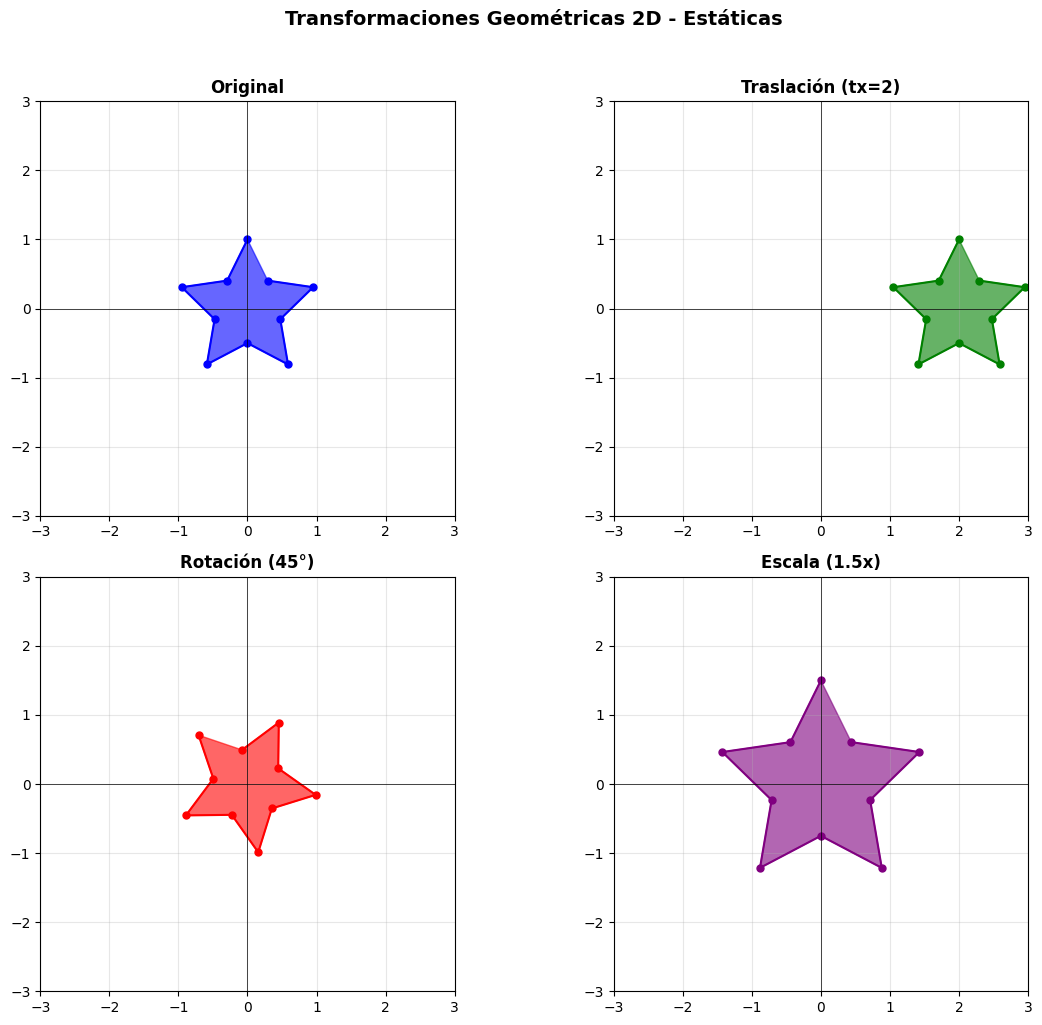

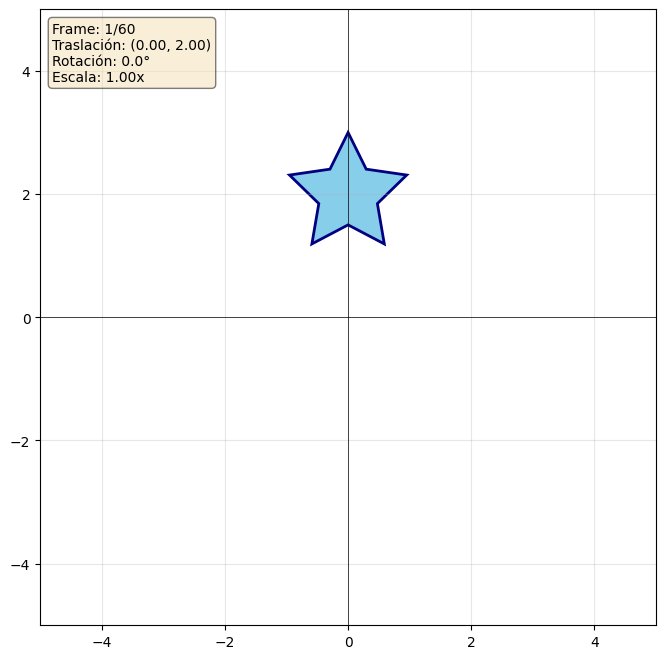

✓ Animación guardada: hola_mundo_visual.gif
  - Frames: 50
  - FPS: 15
  - Duración: 3.3 segundos


In [6]:
# ============================================================================
# HOLA MUNDO VISUAL - Transformaciones Geométricas 2D
# ============================================================================
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Rectangle
from matplotlib.animation import FuncAnimation
import imageio
import os

# Configurar matplotlib para Jupyter
%matplotlib inline

# ============================================================================
# 1. DEFINIR LAS MATRICES DE TRANSFORMACIÓN
# ============================================================================

def translation_matrix(tx, ty):
    """Matriz de traslación 2D (coordenadas homogéneas)"""
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

def rotation_matrix(angle_degrees):
    """Matriz de rotación 2D (coordenadas homogéneas)"""
    angle_rad = np.radians(angle_degrees)
    return np.array([
        [np.cos(angle_rad), -np.sin(angle_rad), 0],
        [np.sin(angle_rad), np.cos(angle_rad), 0],
        [0, 0, 1]
    ])

def scaling_matrix(sx, sy):
    """Matriz de escala 2D (coordenadas homogéneas)"""
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

# ============================================================================
# 2. CREAR UNA FIGURA 2D (UNA CASA SIMPLE)
# ============================================================================

def create_house():
    """Crea una casa simple como conjunto de puntos"""
    # Puntos de la casa (coordenadas homogéneas)
    # Base de la casa
    house_base = np.array([
        [-1, -1, 1],
        [1, -1, 1],
        [1, 0, 1],
        [-1, 0, 1]
    ])
    
    # Techo de la casa
    roof = np.array([
        [-1.3, 0, 1],
        [0, 1, 1],
        [1.3, 0, 1]
    ])
    
    return house_base, roof

def create_star(n_points=5, outer_radius=1.0, inner_radius=0.5):
    """Crea una estrella de n puntas"""
    points = []
    for i in range(n_points * 2):
        angle = np.pi / 2 + i * np.pi / n_points
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        points.append([x, y, 1])
    
    return np.array(points)

# ============================================================================
# 3. APLICAR TRANSFORMACIONES
# ============================================================================

def apply_transformation(points, transformation_matrix):
    """Aplica una matriz de transformación a un conjunto de puntos"""
    return (transformation_matrix @ points.T).T

def transform_shape(points, transformations):
    """
    Aplica múltiples transformaciones en secuencia
    transformations: lista de tuplas (tipo, parámetros)
    Ejemplo: [('translate', (2, 0)), ('rotate', 45), ('scale', (1.5, 1.5))]
    """
    result = points.copy()
    
    for trans_type, params in transformations:
        if trans_type == 'translate':
            matrix = translation_matrix(params[0], params[1])
        elif trans_type == 'rotate':
            matrix = rotation_matrix(params)
        elif trans_type == 'scale':
            matrix = scaling_matrix(params[0], params[1])
        
        result = apply_transformation(result, matrix)
    
    return result

# ============================================================================
# 4. VISUALIZAR TRANSFORMACIONES ESTÁTICAS
# ============================================================================

def plot_static_transformations():
    """Muestra las transformaciones estáticas básicas"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Crear forma original (estrella)
    original_shape = create_star()
    
    # Transformaciones
    translated = transform_shape(original_shape, [('translate', (2, 0))])
    rotated = transform_shape(original_shape, [('rotate', 45)])
    scaled = transform_shape(original_shape, [('scale', (1.5, 1.5))])
    combined = transform_shape(original_shape, [
        ('translate', (0, 2)),
        ('rotate', 30),
        ('scale', (1.2, 1.2))
    ])
    
    shapes = [
        (original_shape, 'Original', 'blue'),
        (translated, 'Traslación (tx=2)', 'green'),
        (rotated, 'Rotación (45°)', 'red'),
        (scaled, 'Escala (1.5x)', 'purple')
    ]
    
    for idx, (shape, title, color) in enumerate(shapes):
        ax = axes[idx // 2, idx % 2]
        ax.fill(shape[:, 0], shape[:, 1], alpha=0.6, color=color)
        ax.plot(shape[:, 0], shape[:, 1], 'o-', color=color, markersize=5)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
    
    plt.suptitle('Transformaciones Geométricas 2D - Estáticas', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 5. CREAR ANIMACIÓN
# ============================================================================

def create_animation(num_frames=100, fps=20):
    """
    Crea una animación combinando todas las transformaciones
    """
    # Crear forma inicial
    original_shape = create_star()
    
    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    
    # Inicializar polygon
    polygon = Polygon(original_shape[:, :2], closed=True, 
                      fill=True, facecolor='skyblue', 
                      edgecolor='navy', linewidth=2)
    ax.add_patch(polygon)
    
    # Texto para mostrar el frame
    text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    def animate(frame):
        # Calcular transformaciones en función del tiempo
        t = frame / num_frames
        
        # Traslación circular
        tx = 2 * np.sin(2 * np.pi * t)
        ty = 2 * np.cos(2 * np.pi * t)
        
        # Rotación continua
        rotation_angle = 360 * t
        
        # Escala oscilante
        scale_factor = 1 + 0.3 * np.sin(4 * np.pi * t)
        
        # Aplicar todas las transformaciones
        transformed = transform_shape(original_shape, [
            ('translate', (tx, ty)),
            ('rotate', rotation_angle),
            ('scale', (scale_factor, scale_factor))
        ])
        
        # Actualizar polygon
        polygon.set_xy(transformed[:, :2])
        
        # Cambiar color cíclicamente
        colors = ['skyblue', 'lightgreen', 'lightcoral', 'plum', 'khaki']
        color_idx = int(t * len(colors)) % len(colors)
        polygon.set_facecolor(colors[color_idx])
        
        # Actualizar texto
        text.set_text(f'Frame: {frame + 1}/{num_frames}\n'
                     f'Traslación: ({tx:.2f}, {ty:.2f})\n'
                     f'Rotación: {rotation_angle:.1f}°\n'
                     f'Escala: {scale_factor:.2f}x')
        
        return polygon, text
    
    # Crear animación
    anim = FuncAnimation(fig, animate, frames=num_frames, 
                        interval=1000/fps, blit=True)
    
    return fig, anim

# ============================================================================
# 6. EXPORTAR COMO GIF
# ============================================================================

def export_as_gif(anim, filename='transformaciones.gif', fps=20):
    """
    Exporta la animación como GIF usando imageio
    Basado en: https://towardsdatascience.com/the-simplest-way-of-making-gifs-and-math-videos-with-python-aec41da74c6e
    """
    from matplotlib.animation import PillowWriter
    
    # Guardar como GIF temporalmente frame por frame
    temp_dir = 'temp_frames'
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir)
    
    # Extraer frames
    frames = []
    for i in range(len(anim._draw_seq)):
        fig = anim._fig
        anim.event_source.stop()
        
    # Método alternativo: guardar directamente
    writer = PillowWriter(fps=fps)
    anim.save(filename, writer=writer)
    
    print(f"✓ GIF guardado como: {filename}")
    
    # Limpiar
    if os.path.exists(temp_dir):
        import shutil
        shutil.rmtree(temp_dir)

# ============================================================================
# 7. ANIMACIÓN SIMPLIFICADA (RECOMENDADA PARA JUPYTER)
# ============================================================================

def create_simple_animation_gif(filename='hola_mundo_visual.gif', 
                                 num_frames=50, fps=15):
    """
    Crea y guarda una animación simple como GIF
    """
    from matplotlib.animation import PillowWriter
    
    original_shape = create_star()
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title('Animacoin', 
                 fontsize=12, fontweight='bold')
    
    polygon = Polygon(original_shape[:, :2], closed=True, 
                      fill=True, facecolor='skyblue', 
                      edgecolor='navy', linewidth=2)
    ax.add_patch(polygon)
    
    def animate(frame):
        t = frame / num_frames
        
        # Transformaciones combinadas
        tx = 2 * np.sin(2 * np.pi * t)
        ty = 1.5 * np.cos(2 * np.pi * t)
        rotation_angle = 360 * t
        scale_factor = 1 + 0.3 * np.sin(4 * np.pi * t)
        
        transformed = transform_shape(original_shape, [
            ('translate', (tx, ty)),
            ('rotate', rotation_angle),
            ('scale', (scale_factor, scale_factor))
        ])
        
        polygon.set_xy(transformed[:, :2])
        
        # Colores dinámicos
        hue = t
        polygon.set_facecolor(plt.cm.hsv(hue))
        
        return polygon,
    
    anim = FuncAnimation(fig, animate, frames=num_frames, 
                        interval=1000/fps, blit=True)
    
    # Guardar como GIF
    writer = PillowWriter(fps=fps)
    anim.save(filename, writer=writer)
    plt.close(fig)
    
    print(f"✓ Animación guardada: {filename}")
    print(f"  - Frames: {num_frames}")
    print(f"  - FPS: {fps}")
    print(f"  - Duración: {num_frames/fps:.1f} segundos")
    
    return filename

# ============================================================================
# EJECUCIÓN DEL TALLER
# ============================================================================

print("=" * 70)
print("HOLA MUNDO - Jupyter")
print("=" * 70)

# Paso 1: Mostrar transformaciones estáticas
plot_static_transformations()

# Paso 2: Crear y mostrar animación en Jupyter
fig, anim = create_animation(num_frames=60, fps=15)
plt.show()

# Paso 3: Exportar como GIF
gif_file = create_simple_animation_gif(
    filename='hola_mundo_visual.gif',
    num_frames=50,
    fps=15
)